<a href="https://colab.research.google.com/github/bianbalsari/bianbalsari/blob/main/wave_climate_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELDA 1: LIBRERÍAS
# ============================================================
!pip install cartopy --quiet

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print("✅ Librerías importadas correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 80.2 MB/s eta 0:00:00
✅ Librerías importadas correctamente.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import xarray as xr

# ========================================================/home/Estudiante/Descargas/cmems_mod_glo_wav_my_0.2deg_PT3H-i_1782144657634.nc$0====
# CELDA 2: CARGA DEL DATASET ORIGINAL
# ============================================================
# Si tu archivo está en Google Drive, descomenta las siguientes líneas y ejecuta:
# from google.colab import drive
# drive.mount('/content/drive')

# ---> IMPORTANTE: Poner la ruta correcta de tu archivo de Copernicus <---
# Asegúrate de que el archivo 'cmems_mod_glo_wav_my_0.2deg_PT3H-i_1782144657634.nc' esté subido a tu entorno de Colab
# o la ruta a tu Google Drive sea la correcta (ej: '/content/drive/MyDrive/ruta/a/tu/archivo.nc')
archivo_nc = "/content/drive/MyDrive/DOCTORADO TODO /WAVERYS - HS,TP, DIREC/Todo + Sea, Swell, 1980-2026 (Mar Chiquita a Miramar). Nodos costeros + 50 m profund AP./cmems_mod_glo_wav_my_0.2deg_PT3H-i_1782144657634.nc"
print("Cargando el archivo NetCDF original a la memoria...")
# Cargamos todo tal cual está, sin recortes
ds_original = xr.open_dataset(archivo_nc)

print("\n✅ Dataset crudo cargado con éxito:")
print(f"  -> Tiempo total disponible: {ds_original.dims['time']} registros")
print(f"  -> Grilla: {ds_original.dims['latitude']} latitudes x {ds_original.dims['longitude']} longitudes")

Cargando el archivo NetCDF original a la memoria...

✅ Dataset crudo cargado con éxito:
  -> Tiempo total disponible: 135376 registros
  -> Grilla: 3 latitudes x 10 longitudes


/tmp/ipykernel_711/2547301910.py:19: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  -> Tiempo total disponible: {ds_original.dims['time']} registros")
/tmp/ipykernel_711/2547301910.py:20: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  -> Grilla: {ds_original.dims['latitude']} latitudes x {ds_original.dims['longitude']} longitudes")


Generando mapa cartográfico del área de estudio...


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


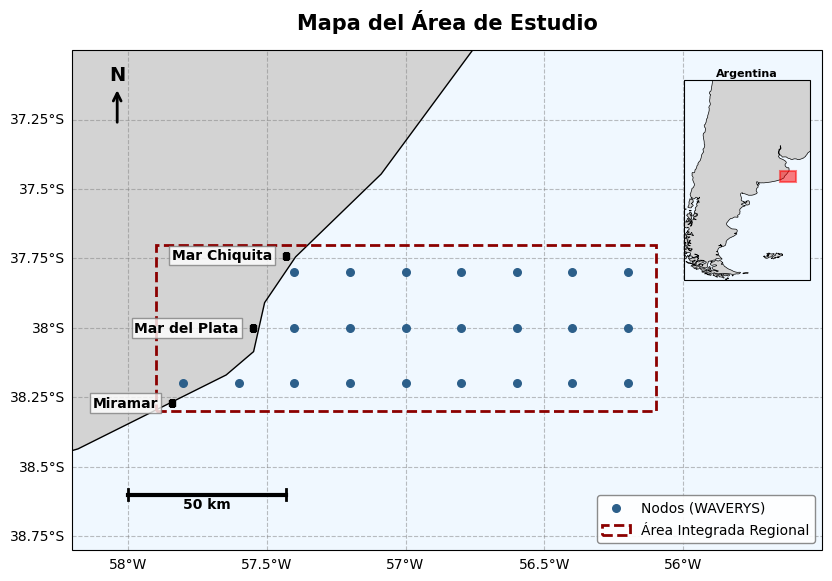

In [4]:
# ============================================================
# CELDA 3: MAPA DEL ÁREA DE ESTUDIO (AGUAS ADENTRO)
# ============================================================
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

print("Generando mapa cartográfico del área de estudio...")

# =====================================================
# SOLUCIÓN AL ERROR: Definimos ds_estudio acá mismo
# Recortamos los 30 años (1994-2026) de tu dataset original 'ds_original'
# =====================================================
ds_estudio = ds_original.sel(time=slice('1994', '2026'))

# 1. Extraemos las coordenadas de los nodos válidos
df_coords = ds_estudio['VHM0'].isel(time=0).to_dataframe().reset_index()
nodos_oceanicos = df_coords.dropna(subset=['VHM0'])[['latitude', 'longitude']]

# 2. Configuramos la figura principal
fig = plt.figure(figsize=(10, 8))
ax = fig.add_axes([0.1, 0.1, 0.75, 0.85], projection=ccrs.PlateCarree())

# Extensión espacial: Ampliamos para ver la costa
extent_main = [-58.2, -55.5, -38.8, -37.0]
ax.set_extent(extent_main, crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='aliceblue', zorder=1)
ax.coastlines(resolution='50m', color='black', linewidth=1, zorder=3)

# 3. Graficamos los nodos y el polígono
ax.scatter(nodos_oceanicos['longitude'], nodos_oceanicos['latitude'],
           color='#2c5f8a', marker='o', s=30, transform=ccrs.PlateCarree(),
           zorder=5, label='Nodos (WAVERYS)')

# Trazamos un polígono punteado para enmarcar el área integrada
lon_min, lon_max = nodos_oceanicos['longitude'].min(), nodos_oceanicos['longitude'].max()
lat_min, lat_max = nodos_oceanicos['latitude'].min(), nodos_oceanicos['latitude'].max()

rect_area = mpatches.Rectangle((lon_min - 0.1, lat_min - 0.1),
                               width=(lon_max - lon_min + 0.2),
                               height=(lat_max - lat_min + 0.2),
                               linewidth=2, edgecolor='darkred', facecolor='none',
                               linestyle='--', transform=ccrs.PlateCarree(), zorder=6,
                               label='Área Integrada Regional')
ax.add_patch(rect_area)

# =====================================================
# 4. CIUDADES DE REFERENCIA (CON FONDO BLANCO PARA RESALTAR)
# =====================================================
ciudades = {
    'Mar Chiquita':  (-57.43, -37.74),
    'Mar del Plata': (-57.55, -38.00),
    'Miramar':       (-57.84, -38.27)
}

for ciudad, (lon_c, lat_c) in ciudades.items():
    # Dibujamos un punto negro cuadrado para la ciudad
    ax.scatter(lon_c, lat_c, color='black', marker='s', s=25,
               transform=ccrs.PlateCarree(), zorder=10)

    # Agregamos la etiqueta desplazada hacia el continente con recuadro blanco
    ax.text(lon_c - 0.05, lat_c, ciudad, transform=ccrs.PlateCarree(),
            fontsize=10, fontweight='bold', color='black',
            ha='right', va='center', zorder=11,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', pad=2.0))

# Activamos el cuadro de referencias (leyenda) ABAJO A LA DERECHA
ax.legend(loc='lower right', fontsize=10, framealpha=0.9, edgecolor='gray')

# Grilla de coordenadas
gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5, zorder=4)
gl.top_labels = False
gl.right_labels = False

# 5. Brújula (Norte) - ARRIBA A LA IZQUIERDA
ax.annotate('N', xy=(0.06, 0.85), xytext=(0.06, 0.95),
            xycoords='axes fraction', fontsize=14, fontweight='bold',
            ha='center', va='center',
            arrowprops=dict(arrowstyle='<-', color='black', lw=2), zorder=6)

# 6. Escala ~50 km - ABAJO A LA IZQUIERDA
x0, y0 = -58.0, -38.6
dx = 0.57
ax.plot([x0, x0+dx], [y0, y0], color='black', linewidth=3, transform=ccrs.PlateCarree(), zorder=6)
ax.plot([x0, x0], [y0-0.02, y0+0.02], color='black', linewidth=2, transform=ccrs.PlateCarree(), zorder=6)
ax.plot([x0+dx, x0+dx], [y0-0.02, y0+0.02], color='black', linewidth=2, transform=ccrs.PlateCarree(), zorder=6)
ax.text(x0+dx/2, y0-0.05, '50 km', transform=ccrs.PlateCarree(), ha='center', fontsize=10, fontweight='bold', zorder=6)

# =====================================================
# 7. INSET ARGENTINA
ax_inset = fig.add_axes([0.7, 0.55, 0.15, 0.25], projection=ccrs.PlateCarree())
ax_inset.set_extent([-75, -53, -56, -21], crs=ccrs.PlateCarree())
ax_inset.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', zorder=1)
ax_inset.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='aliceblue', zorder=1)
ax_inset.coastlines(resolution='50m', linewidth=0.5, zorder=2)

# Polígono rojo del inset
ancho_rect = extent_main[1] - extent_main[0]
alto_rect  = extent_main[3] - extent_main[2]
rect = mpatches.Rectangle((extent_main[0], extent_main[2]), width=ancho_rect, height=alto_rect,
                          linewidth=1.5, edgecolor='red', facecolor='red', alpha=0.5,
                          transform=ccrs.PlateCarree(), zorder=5)
ax_inset.add_patch(rect)
ax_inset.set_title('Argentina', fontsize=8, fontweight='bold', pad=3)

# =====================================================
# 8. TÍTULO PRINCIPAL
# =====================================================
ax.set_title('Mapa del Área de Estudio', fontsize=15, fontweight='bold', pad=15)

plt.show()


In [5]:
# ============================================================
# CELDA 4: EXTRACCIÓN REGIONAL Y ESTADÍSTICOS BÁSICOS (Punto 1a)
# ============================================================
import numpy as np
import pandas as pd
from IPython.display import display

print("-- PUNTO 1a: EXTRACCIÓN Y ESTADÍSTICOS REGIONALES ---")

# 1. Definimos las fechas de control para todo el TP (fácilmente modificable)
fecha_inicio = '1994'
fecha_fin    = '2026'

# Filtramos temporalmente el dataset original
ds_estudio = ds_original.sel(time=slice(fecha_inicio, fecha_fin))

# 2. Integramos espacialmente (promedio regional de toda la grilla aguas adentro)
# Esto colapsa la latitud y longitud creando una serie temporal pura 1D regional
ds_regional = ds_estudio.mean(dim=['latitude', 'longitude'])

# 3. Extraemos los vectores de datos limpios de NaNs
Hs_regional = ds_regional['VHM0'].values[~np.isnan(ds_regional['VHM0'].values)]
Tp_regional = ds_regional['VTPK'].values[~np.isnan(ds_regional['VTPK'].values)]
tiempo_dt   = pd.to_datetime(ds_regional['time'].values)

# 4. Función para calcular las métricas solicitadas
def obtener_metricas(datos):
    return {
        'Media': f"{np.mean(datos):.2f}",
        'Desvío Estándar': f"{np.std(datos):.2f}",
        'Mediana (Otro)': f"{np.median(datos):.2f}", # Elegido para justificar asimetría estadística
        'Percentil 90': f"{np.percentile(datos, 90):.2f}",
        'Percentil 95': f"{np.percentile(datos, 95):.2f}",
        'Percentil 99': f"{np.percentile(datos, 99):.2f}"
    }

# Creamos el DataFrame para mostrarlo como una hermosa tabla de tesis
resumen_datos = {
    'Métrica': ['Media', 'Desvío Estándar', 'Mediana (Otro)', 'Percentil 90', 'Percentil 95', 'Percentil 99'],
    'Hs — Altura (m)': list(obtener_metricas(Hs_regional).values()),
    'Tp — Período (s)': list(obtener_metricas(Tp_regional).values())
}

df_estadisticos = pd.DataFrame(resumen_datos)

# Estilizamos la tabla con Pandas
tabla_pro = (
    df_estadisticos.style
    .hide(axis="index")
    .set_caption(f"📊 CLIMATOLOGÍA GENERAL REGIONAL ({fecha_inicio} - {fecha_fin})")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#1a3a5c'), ('margin-bottom', '8px')]},
        {'selector': 'thead th', 'props': [('background-color', '#1a3a5c'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'tbody td', 'props': [('text-align', 'center'), ('border', '1px solid lightgray')]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#dce9f5')]}
    ])
)

display(tabla_pro)
print(f"\nSeries temporales listas. Registros en el período: {len(tiempo_dt)}")

-- PUNTO 1a: EXTRACCIÓN Y ESTADÍSTICOS REGIONALES ---


Métrica,Hs — Altura (m),Tp — Período (s)
Media,1.54,8.80
Desvío Estándar,0.61,2.07
Mediana (Otro),1.40,8.88
Percentil 90,2.33,11.35
Percentil 95,2.73,12.04
Percentil 99,3.66,13.75



Series temporales listas. Registros en el período: 94464


Generando curvas de distribución acumulativa empírica (ECDF)...


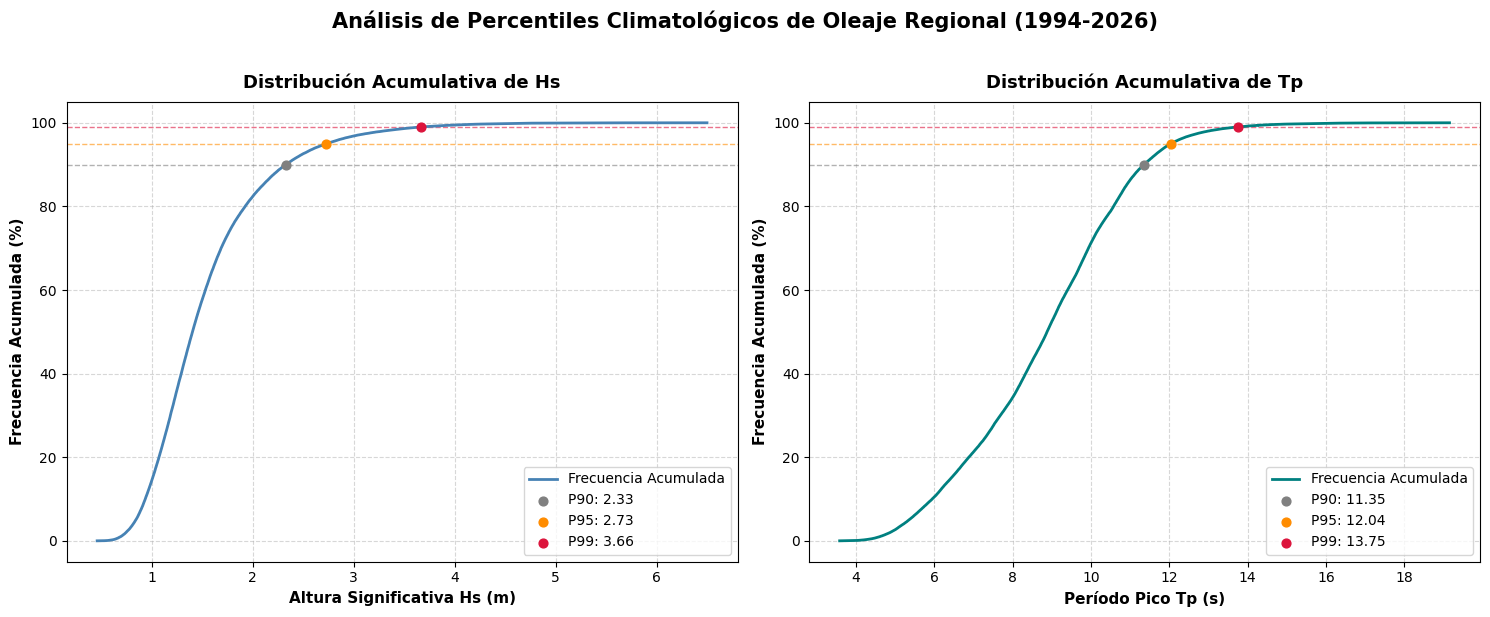

In [6]:
# ============================================================
# CELDA 5: GRÁFICO DE DISTRIBUCIÓN ACUMULATIVA (Punto 1b)
# ============================================================
import matplotlib.pyplot as plt

print("Generando curvas de distribución acumulativa empírica (ECDF)...")

def graficar_ecdf(datos, ax, xlabel, titulo, color_curva):
    # Ordenamos de menor a mayor para la frecuencia acumulada
    x = np.sort(datos)
    y = np.arange(1, len(x) + 1) / len(x) * 100

    # Curva empírica acumulada
    ax.plot(x, y, label='Frecuencia Acumulada', color=color_curva, linewidth=2, zorder=3)

    # Calculamos los percentiles clave
    p90, p95, p99 = np.percentile(datos, [90, 95, 99])

    # Trazamos las líneas y puntos de los percentiles requeridos
    percentiles = [(90, p90, 'gray'), (95, p95, 'darkorange'), (99, p99, 'crimson')]
    for pct, valor, color in percentiles:
        ax.axhline(pct, color=color, linestyle='--', alpha=0.6, linewidth=1, zorder=2)
        ax.scatter(valor, pct, color=color, s=40, zorder=4,
                   label=f'P{pct}: {valor:.2f}')

    ax.set_xlabel(xlabel, fontweight='bold', fontsize=11)
    ax.set_ylabel('Frecuencia Acumulada (%)', fontweight='bold', fontsize=11)
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5, zorder=1)

# Configuramos la figura con dos paneles separados
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

graficar_ecdf(Hs_regional, axes[0], 'Altura Significativa Hs (m)', 'Distribución Acumulativa de Hs', 'steelblue')
graficar_ecdf(Tp_regional, axes[1], 'Período Pico Tp (s)', 'Distribución Acumulativa de Tp', 'teal')

plt.suptitle('Análisis de Percentiles Climatológicos de Oleaje Regional (1994-2026)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Generando rosas de oleaje con escala dinámica y alto contraste...


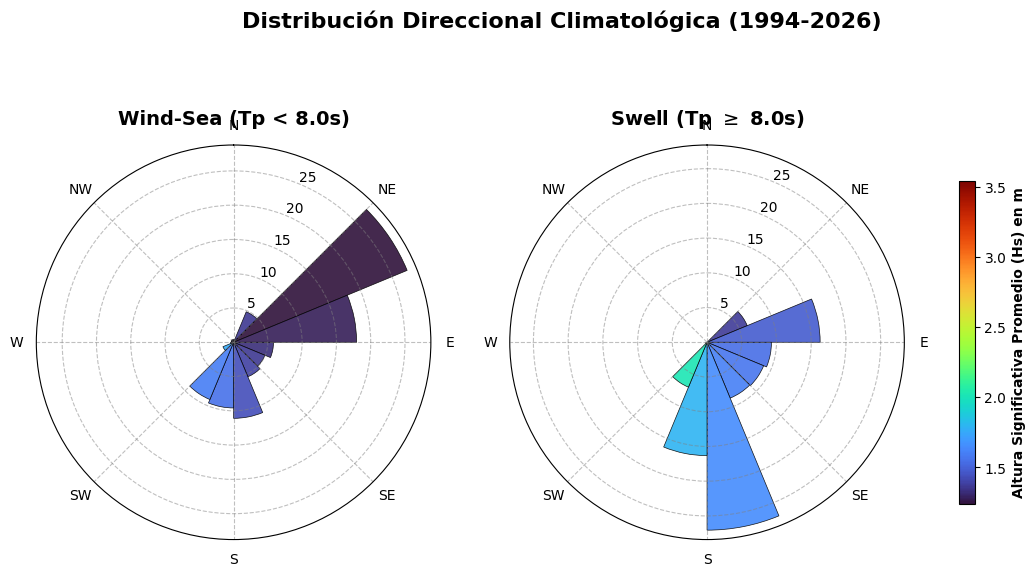

In [7]:
# ============================================================
# CELDA: DISTRIBUCIÓN DIRECCIONAL (ROSAS DE OLEAJE ALTO CONTRASTE)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print("Generando rosas de oleaje con escala dinámica y alto contraste...")

# Definición de df_waves movida desde CELDA 10 para resolver NameError
df_waves = ds_regional[['VHM0', 'VTPK', 'VPED']].to_dataframe().reset_index()

# 1. Separar datos en Wind-Sea y Swell usando el umbral de 8 segundos
df_sea = df_waves[df_waves['VTPK'] < 8.0]
df_swell = df_waves[df_waves['VTPK'] >= 8.0]

# 2. Función para calcular la frecuencia y la Hs media por sector direccional
def calcular_rosa(df, bins=16):
    dir_bins = np.linspace(0, 360, bins + 1)
    width = 2 * np.pi / bins
    freqs, mean_hs = [], []

    for i in range(bins):
        mask = (df['VPED'] >= dir_bins[i]) & (df['VPED'] < dir_bins[i+1])
        sector = df[mask]
        freqs.append(len(sector) / len(df) * 100 if len(df) > 0 else 0)
        mean_hs.append(sector['VHM0'].mean() if len(sector) > 0 else np.nan)

    angles = np.deg2rad(dir_bins[:-1] + (360 / bins) / 2)
    return angles, freqs, mean_hs, width

angles_sea, freq_sea, hs_sea, width = calcular_rosa(df_sea)
angles_swell, freq_swell, hs_swell, _ = calcular_rosa(df_swell)

# 3. AJUSTE CLAVE: Límites dinámicos y Paleta Térmica
# Juntamos todos los valores válidos para encontrar los extremos exactos
todos_los_hs = [h for h in hs_sea + hs_swell if not np.isnan(h)]
vmin_val = min(todos_los_hs)
vmax_val = max(todos_los_hs)

# Usamos la paleta 'turbo' que resalta variaciones pequeñas de manera muy evidente
cmap = plt.cm.turbo
norm = mcolors.Normalize(vmin=vmin_val, vmax=vmax_val)

# 4. Configuración de la Figura
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(14, 6))
fig.suptitle('Distribución Direccional Climatológica (1994-2026)', fontsize=16, fontweight='bold', y=1.05)

def formatear_polar(ax, titulo):
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
    ax.grid(color='gray', linestyle='--', alpha=0.5)

formatear_polar(ax1, 'Wind-Sea (Tp < 8.0s)')
formatear_polar(ax2, r'Swell (Tp $\geq$ 8.0s)')

# 5. Graficar las barras polares
bars1 = ax1.bar(angles_sea, freq_sea, width=width, bottom=0.0,
                color=cmap(norm(hs_sea)), edgecolor='black', linewidth=0.5, alpha=0.9)
bars2 = ax2.bar(angles_swell, freq_swell, width=width, bottom=0.0,
                color=cmap(norm(hs_swell)), edgecolor='black', linewidth=0.5, alpha=0.9)

# 6. Barra de colores compartida adaptada a la nueva escala
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation='vertical', shrink=0.7, pad=0.05)
cbar.set_label('Altura Significativa Promedio (Hs) en m', fontweight='bold')

plt.show()

Generando rosas de oleaje con escala fija y alto contraste...


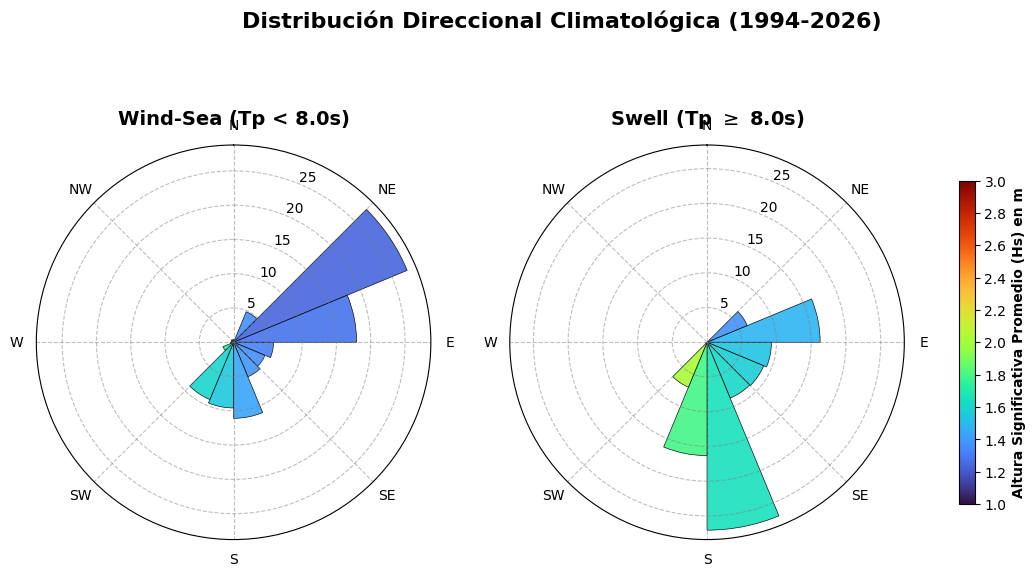

In [8]:
# ============================================================
# CELDA: DISTRIBUCIÓN DIRECCIONAL (ROSAS DE OLEAJE ALTO CONTRASTE)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print("Generando rosas de oleaje con escala fija y alto contraste...")

# Definición de df_waves movida desde CELDA 10 para resolver NameError
df_waves = ds_regional[['VHM0', 'VTPK', 'VPED']].to_dataframe().reset_index()

# 1. Separar datos en Wind-Sea y Swell usando el umbral de 8 segundos
df_sea = df_waves[df_waves['VTPK'] < 8.0]
df_swell = df_waves[df_waves['VTPK'] >= 8.0]

# 2. Función para calcular la frecuencia y la Hs media por sector direccional
def calcular_rosa(df, bins=16):
    dir_bins = np.linspace(0, 360, bins + 1)
    width = 2 * np.pi / bins
    freqs, mean_hs = [], []

    for i in range(bins):
        mask = (df['VPED'] >= dir_bins[i]) & (df['VPED'] < dir_bins[i+1])
        sector = df[mask]
        freqs.append(len(sector) / len(df) * 100 if len(df) > 0 else 0)
        mean_hs.append(sector['VHM0'].mean() if len(sector) > 0 else np.nan)

    angles = np.deg2rad(dir_bins[:-1] + (360 / bins) / 2)
    return angles, freqs, mean_hs, width

angles_sea, freq_sea, hs_sea, width = calcular_rosa(df_sea)
angles_swell, freq_swell, hs_swell, _ = calcular_rosa(df_swell)

# =====================================================
# 3. AJUSTE CLAVE: Límites fijos (1 a 3) y Paleta Térmica
# =====================================================
vmin_val = 1.0
vmax_val = 3.0

# Usamos la paleta 'turbo' que resalta variaciones pequeñas de manera muy evidente
cmap = plt.cm.turbo
norm = mcolors.Normalize(vmin=vmin_val, vmax=vmax_val)

# 4. Configuración de la Figura
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(14, 6))
fig.suptitle('Distribución Direccional Climatológica (1994-2026)', fontsize=16, fontweight='bold', y=1.05)

def formatear_polar(ax, titulo):
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
    ax.grid(color='gray', linestyle='--', alpha=0.5)

formatear_polar(ax1, 'Wind-Sea (Tp < 8.0s)')
formatear_polar(ax2, r'Swell (Tp $\geq$ 8.0s)')

# 5. Graficar las barras polares
bars1 = ax1.bar(angles_sea, freq_sea, width=width, bottom=0.0,
                color=cmap(norm(hs_sea)), edgecolor='black', linewidth=0.5, alpha=0.9)
bars2 = ax2.bar(angles_swell, freq_swell, width=width, bottom=0.0,
                color=cmap(norm(hs_swell)), edgecolor='black', linewidth=0.5, alpha=0.9)

# =====================================================
# 6. Barra de colores con particiones cada 0.2
# =====================================================
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Generamos un arreglo numérico desde 1.0 hasta 3.0, saltando de a 0.2
ticks_escala = np.arange(1.0, 3.1, 0.2)

cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation='vertical', shrink=0.7, pad=0.05, ticks=ticks_escala)
cbar.set_label('Altura Significativa Promedio (Hs) en m', fontweight='bold')

plt.show()

--- PUNTO 2: ANÁLISIS ESTACIONAL DE OLEAJE ---


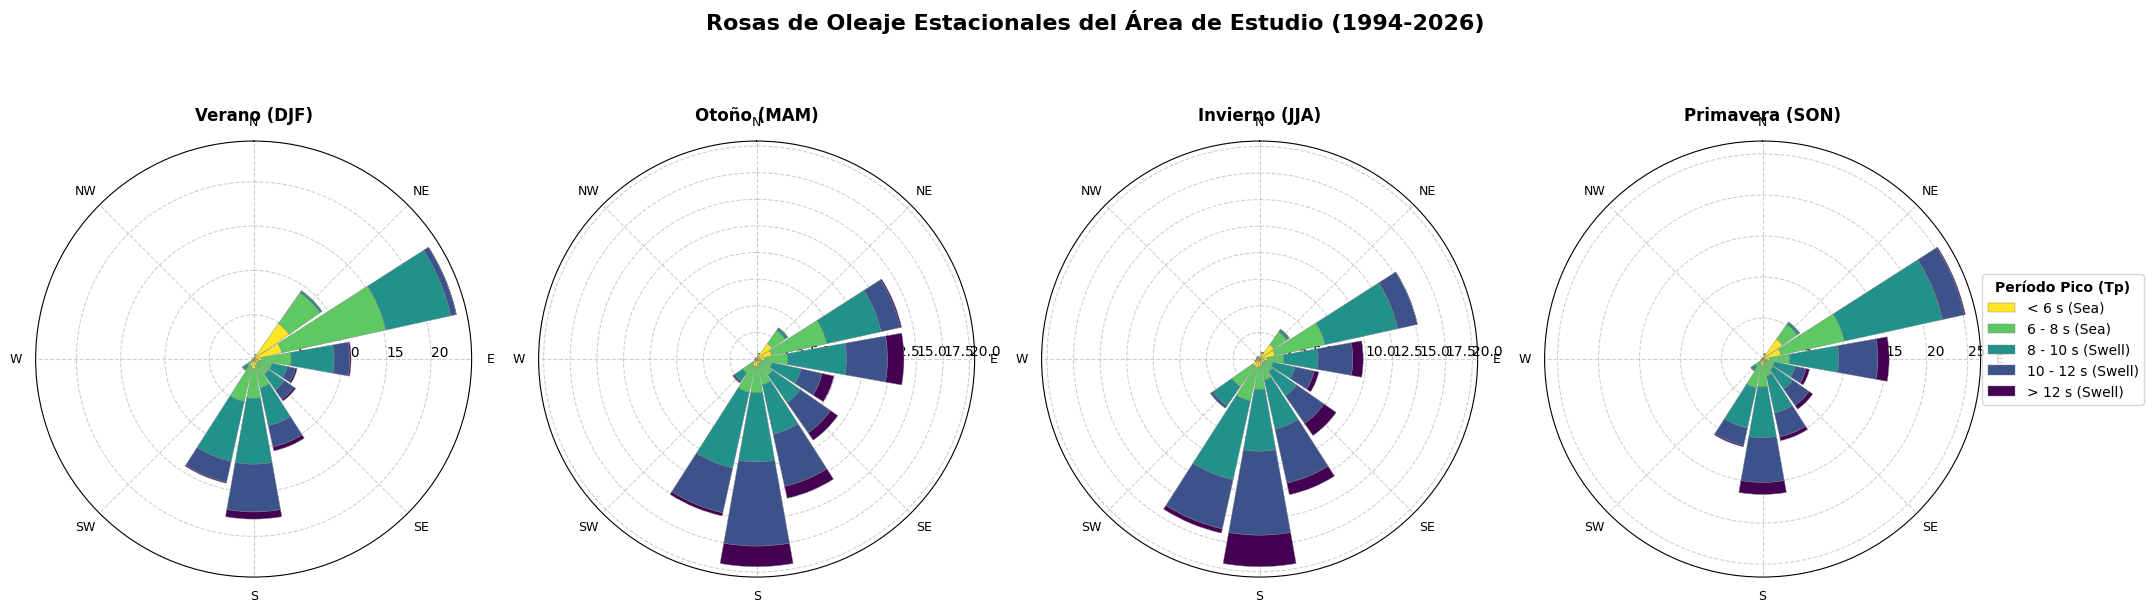


--- PUNTO 2b: ESTADÍSTICOS ESTACIONALES ---


Estación,Hs Máxima (m),Hs Mínima (m),Hs Media (m),Tp Máximo (s),Tp Mínimo (s),Tp Medio (s)
Verano (DJF),5.32,0.48,1.44,16.62,3.59,8.15
Otoño (MAM),6.19,0.47,1.58,17.95,3.76,9.16
Invierno (JJA),6.50,0.46,1.61,19.15,3.59,9.11
Primavera (SON),5.68,0.55,1.54,18.93,3.68,8.78


In [9]:
# ============================================================
# CELDA 7: ANÁLISIS ESTACIONAL (Puntos 2a y 2b)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print("--- PUNTO 2: ANÁLISIS ESTACIONAL DE OLEAJE ---")

# =====================================================
# SOLUCIÓN DE SEGURIDAD: Chequeo de variables en memoria
# =====================================================
try:
    ds_regional
except NameError:
    print("⚠️ Error: No se encontró 'ds_regional' en la memoria.")
    print("Por favor, ejecutá la CELDA 4 primero para extraer la serie regional.")
else:
    # Definimos los meses para cada estación (Hemisferio Sur)
    estaciones = {
        'Verano (DJF)': [12, 1, 2],
        'Otoño (MAM)': [3, 4, 5],
        'Invierno (JJA)': [6, 7, 8],
        'Primavera (SON)': [9, 10, 11]
    }

    # =====================================================
    # PUNTO 2a: ROSAS DIRECCIONALES ESTACIONALES
    # =====================================================
    def rosa_apilada_Tp(direcciones, periodos, ax, titulo):
        mask = ~np.isnan(direcciones) & ~np.isnan(periodos)
        dir_valid = direcciones[mask]
        tp_valid = periodos[mask]

        if len(dir_valid) == 0:
            ax.set_title(titulo)
            return

        n_sectores = 16
        ancho = 360.0 / n_sectores
        bins_dir = np.arange(-ancho/2, 360 + ancho/2, ancho)

        # Rangos de Tp para la paleta de colores (Sea vs Swell)
        bins_tp = [0, 6, 8, 10, 12, np.inf]
        colores = ['#fde725', '#5ec962', '#21918c', '#3b528b', '#440154']
        etiquetas_tp = ['< 6 s (Sea)', '6 - 8 s (Sea)', '8 - 10 s (Swell)', '10 - 12 s (Swell)', '> 12 s (Swell)']

        dir_mod = np.where(dir_valid >= 360 - ancho/2, dir_valid - 360, dir_valid)
        frecuencias = np.zeros((len(bins_tp)-1, n_sectores))
        total_datos = len(dir_valid)

        for i in range(len(bins_tp)-1):
            for j in range(n_sectores):
                d_min = bins_dir[j]
                d_max = bins_dir[j+1]
                mask_bin = (dir_mod >= d_min) & (dir_mod < d_max) & \
                           (tp_valid >= bins_tp[i]) & (tp_valid < bins_tp[i+1])
                frecuencias[i, j] = np.sum(mask_bin) / total_datos * 100

        angulos = np.deg2rad(np.arange(0, 360, ancho))
        bottom = np.zeros(n_sectores)

        for i in range(len(bins_tp)-1):
            ax.bar(angulos, frecuencias[i], width=np.deg2rad(ancho*0.9),
                   bottom=bottom, color=colores[i], edgecolor='gray', linewidth=0.3,
                   label=etiquetas_tp[i], zorder=3)
            bottom += frecuencias[i]

        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)
        ax.set_title(titulo, fontsize=12, fontweight='bold', pad=15)
        ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
        ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'], fontsize=9)
        ax.set_rlabel_position(90)
        ax.grid(True, linestyle='--', alpha=0.6, zorder=1)

    fig, axes = plt.subplots(1, 4, figsize=(22, 6), subplot_kw={'projection': 'polar'})

    # Lista para guardar estadísticas (Punto 2b)
    stats_estacionales = []

    for i, (estacion, meses) in enumerate(estaciones.items()):
        # Filtramos los datos de la serie regional según los meses
        ds_est = ds_regional.sel(time=ds_regional['time.month'].isin(meses))

        direcciones = ds_est['VPED'].values
        periodos    = ds_est['VTPK'].values
        alturas     = ds_est['VHM0'].values

        # Graficamos la rosa en el panel correspondiente
        rosa_apilada_Tp(direcciones, periodos, axes[i], estacion)

        # Calculamos estadísticos limpios de NaNs
        hs_valid = alturas[~np.isnan(alturas)]
        tp_valid = periodos[~np.isnan(periodos)]

        stats_estacionales.append({
            'Estación': estacion,
            'Hs Máxima (m)': f"{np.max(hs_valid):.2f}" if len(hs_valid) > 0 else "-",
            'Hs Mínima (m)': f"{np.min(hs_valid):.2f}" if len(hs_valid) > 0 else "-",
            'Hs Media (m)':  f"{np.mean(hs_valid):.2f}" if len(hs_valid) > 0 else "-",
            'Tp Máximo (s)': f"{np.max(tp_valid):.2f}" if len(tp_valid) > 0 else "-",
            'Tp Mínimo (s)': f"{np.min(tp_valid):.2f}" if len(tp_valid) > 0 else "-",
            'Tp Medio (s)':  f"{np.mean(tp_valid):.2f}" if len(tp_valid) > 0 else "-"
        })

    # Leyenda global
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Período Pico (Tp)", loc='center right',
               bbox_to_anchor=(0.98, 0.5), fontsize=10, title_fontproperties={'weight':'bold'})

    plt.suptitle('Rosas de Oleaje Estacionales del Área de Estudio (1994-2026)',
                 fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()

    # =====================================================
    # PUNTO 2b: ESTADÍSTICOS ESTACIONALES (MÁXIMOS Y MÍNIMOS)
    # =====================================================
    print("\n--- PUNTO 2b: ESTADÍSTICOS ESTACIONALES ---")
    df_stats_est = pd.DataFrame(stats_estacionales)

    tabla_est = (
        df_stats_est.style
        .hide(axis="index")
        .set_caption("🌊 ALTURAS Y PERÍODOS POR ESTACIÓN (MÁXIMOS, MÍNIMOS Y MEDIAS)")
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#1a3a5c'), ('margin-bottom', '8px')]},
            {'selector': 'thead th', 'props': [('background-color', '#1a3a5c'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'tbody td', 'props': [('text-align', 'center'), ('border', '1px solid lightgray')]},
            {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#dce9f5')]}
        ])
    )
    display(tabla_est)

In [10]:
# ============================================================
# CELDA 8: MAPA DE BATIMETRÍA CONTINUA (GEBCO - Punto 3)
# ============================================================
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print("Preparando el mapa de batimetría continua con zoom automático...")

# ---> ¡PONÉ ACÁ LA RUTA DE TU ARCHIVO GEBCO DESCARGADO! <---
archivo_gebco = "/content/gebco_2026_n-37.6_s-38.4_w-58.3_e-56.1.nc"

try:
    ds_gebco = xr.open_dataset(archivo_gebco)
except FileNotFoundError:
    print("⚠️ Archivo no encontrado. Asegurate de cargar el NetCDF de GEBCO y ajustar la ruta.")
else:
    lat_name = 'lat' if 'lat' in ds_gebco.coords else 'latitude'
    lon_name = 'lon' if 'lon' in ds_gebco.coords else 'longitude'

    var_name = 'elevation' if 'elevation' in ds_gebco.data_vars else 'z'
    profundidad = ds_gebco[var_name]

    # Calculamos los límites exactos de tus datos descargados para hacer el zoom
    lon_min, lon_max = float(profundidad[lon_name].min()), float(profundidad[lon_name].max())
    lat_min, lat_max = float(profundidad[lat_name].min()), float(profundidad[lat_name].max())

    # Agregamos un pequeño margen de 0.05 grados para que no quede pegado al borde
    extent_zoom = [lon_min - 0.05, lon_max + 0.05, lat_min - 0.05, lat_max + 0.05]

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_axes([0.1, 0.1, 0.75, 0.85], projection=ccrs.PlateCarree())

    # Aplicamos el zoom exacto
    ax.set_extent(extent_zoom, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', zorder=3)
    ax.coastlines(resolution='50m', color='black', linewidth=1.2, zorder=4)

    # Ploteamos el mapa continuo de profundidades
    im = profundidad.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='Blues_r', vmax=0,
        cbar_kwargs={'label': 'Profundidad / Elevación (m)', 'shrink': 0.8, 'pad': 0.05},
        zorder=1
    )

    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5, zorder=2)
    gl.top_labels = False; gl.right_labels = False

    # Ciudades de referencia
    ciudades = {'Mar Chiquita': (-57.43, -37.74), 'Mar del Plata': (-57.55, -38.00), 'Miramar': (-57.84, -38.27)}
    for ciudad, (lon_c, lat_c) in ciudades.items():
        # Solo dibujamos la ciudad si entra dentro del zoom actual
        if (lon_min - 0.1) < lon_c < (lon_max + 0.1) and (lat_min - 0.1) < lat_c < (lat_max + 0.1):
            ax.scatter(lon_c, lat_c, color='black', marker='s', s=20, transform=ccrs.PlateCarree(), zorder=5)
            ax.text(lon_c - 0.04, lat_c, ciudad, transform=ccrs.PlateCarree(), fontsize=9, fontweight='bold',
                    ha='right', va='center', zorder=6, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    ax.annotate('N', xy=(0.06, 0.85), xytext=(0.06, 0.95), xycoords='axes fraction', fontsize=14, fontweight='bold',
                ha='center', va='center', arrowprops=dict(arrowstyle='<-', color='black', lw=2), zorder=6)

    ax.set_title('Modelo Digital de Elevación Submarina (GEBCO)', fontsize=14, fontweight='bold', pad=15)
    plt.show()

Preparando el mapa de batimetría continua con zoom automático...
⚠️ Archivo no encontrado. Asegurate de cargar el NetCDF de GEBCO y ajustar la ruta.


In [11]:
# ============================================================
# CELDA 9: MAPA DE ISOBATAS SELECCIONADAS (CON SUAVIZADO GAUSSIANO)
# ============================================================
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print("Aplicando filtro espacial y generando mapa de isobatas suavizadas...")

if 'ds_gebco' in locals():
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_axes([0.1, 0.1, 0.75, 0.85], projection=ccrs.PlateCarree())

    # Aplicamos el mismo zoom calculado en la Celda 8
    ax.set_extent(extent_zoom, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', zorder=3)
    ax.coastlines(resolution='50m', color='black', linewidth=1.2, zorder=4)

    # Definimos las curvas de nivel que queremos dibujar
    isobatas_objetivo = [-100, -50, -20]

    # =====================================================
    # SOLUCIÓN AL RUIDO: Aplicamos un filtro Gaussiano a la batimetría
    # El valor sigma=3 suaviza el ruido local de la plataforma plana
    # =====================================================
    profundidad_suavizada = ndimage.gaussian_filter(profundidad.values, sigma=3)

    # Trazamos los contornos usando la matriz suavizada
    contours = ax.contour(
        ds_gebco[lon_name].values,
        ds_gebco[lat_name].values,
        profundidad_suavizada,
        levels=isobatas_objetivo,
        colors=['#08306b', '#2171b5', '#6baed6'], # Gradiente de azules
        linewidths=2.0,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    # Etiquetas numéricas de profundidad
    ax.clabel(contours, fmt='%d m', inline=True, fontsize=10, colors='black')

    # Ciudades de referencia
    for ciudad, (lon_c, lat_c) in ciudades.items():
        if (lon_min - 0.1) < lon_c < (lon_max + 0.1) and (lat_min - 0.1) < lat_c < (lat_max + 0.1):
            ax.scatter(lon_c, lat_c, color='black', marker='s', s=20, transform=ccrs.PlateCarree(), zorder=5)
            ax.text(lon_c - 0.04, lat_c, ciudad, transform=ccrs.PlateCarree(), fontsize=9, fontweight='bold',
                    ha='right', va='center', zorder=6, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5, zorder=1)
    gl.top_labels = False; gl.right_labels = False

    ax.annotate('N', xy=(0.06, 0.85), xytext=(0.06, 0.95), xycoords='axes fraction', fontsize=14, fontweight='bold',
                ha='center', va='center', arrowprops=dict(arrowstyle='<-', color='black', lw=2), zorder=6)

    ax.set_title('Isobatas Relevantes Paralelas a la Línea de Costa', fontsize=14, fontweight='bold', pad=15)
    plt.show()
else:
    print("⚠️ Por favor, ejecutá primero la CELDA 8.")

Aplicando filtro espacial y generando mapa de isobatas suavizadas...
⚠️ Por favor, ejecutá primero la CELDA 8.


In [12]:
# ============================================================
# CELDA 10: IDENTIFICACIÓN DE EXTREMOS Y PROPAGACIÓN (Punto 4a)
# ============================================================
import numpy as np
import pandas as pd
from IPython.display import display

print("Aislando eventos extremos (POT - Percentil 99) y calculando propagación...")

# --- 1. IDENTIFICACIÓN DE EVENTOS EXTREMOS (MÉTODO POT) ---
df_waves = ds_regional[['VHM0', 'VTPK', 'VPED']].to_dataframe().reset_index()
dt_horas = df_waves['time'].diff().mode()[0].total_seconds() / 3600.0
umbral_99 = np.nanpercentile(df_waves['VHM0'].values, 99)

df_waves['is_extreme'] = df_waves['VHM0'] > umbral_99
df_waves['event_id'] = (~df_waves['is_extreme']).cumsum()
eventos = df_waves[df_waves['is_extreme']].copy()

lista_eventos = []
for event_id, group in eventos.groupby('event_id'):
    idx_max = group['VHM0'].idxmax()
    hs_max = group.loc[idx_max, 'VHM0']
    tp_max = group.loc[idx_max, 'VTPK']
    dir_max = group.loc[idx_max, 'VPED']
    fecha_pico = group.loc[idx_max, 'time']
    duracion_hs = len(group) * dt_horas

    lista_eventos.append({
        'Fecha del Pico': fecha_pico,
        'Hs Máxima': f"{hs_max:.2f} m",
        'Tp Medio': f"{tp_max:.1f} s",
        'Dir Media': f"{dir_max:.1f}°",
        'Duración': f"{duracion_hs:.1f} h"
    })

# Ordenamos y preparamos el DataFrame del Top 5
df_top = pd.DataFrame(lista_eventos).sort_values(by='Hs Máxima', ascending=False).reset_index(drop=True)
df_top['Fecha del Pico'] = df_top['Fecha del Pico'].dt.strftime('%d/%m/%Y %H:%M')
# Insertamos la columna "Evento" al principio para igualar el formato de tu imagen
df_top.insert(0, 'Evento', [f'Evento {i+1}' for i in range(len(df_top))])

# --- ESTILO CLÁSICO ACADÉMICO (Igual a la imagen enviada) ---
estilo_base_tabla = [
    # Título centrado, negro y en negrita
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('color', 'black'), ('text-align', 'center'), ('margin-bottom', '15px')]},
    # Encabezado azul oscuro, texto blanco, bordes negros
    {'selector': 'thead th', 'props': [('background-color', '#2d5e85'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center'), ('border', '1px solid black'), ('padding', '8px 15px')]},
    # Celdas con bordes negros sólidos y texto centrado
    {'selector': 'tbody td', 'props': [('text-align', 'center'), ('border', '1px solid black'), ('padding', '8px 15px'), ('color', 'black')]},
    # Filas intercaladas: Pares celeste claro, Impares blanco
    {'selector': 'tbody tr:nth-child(even) td', 'props': [('background-color', '#dae6f2')]},
    {'selector': 'tbody tr:nth-child(odd) td', 'props': [('background-color', '#ffffff')]}
]

# Mostramos el Top 5 con el nuevo estilo
tabla_top_pro = (
    df_top.head(5).style
    .hide(axis="index")
    .set_caption(f"Top 5 Eventos Extremos de Oleaje (P99 = {umbral_99:.2f} m)")
    .set_table_styles(estilo_base_tabla)
)
display(tabla_top_pro)

# --- 2. SELECCIÓN DE ESCENARIOS PARA PROPAGACIÓN ---
fecha_escenario_1 = '1999-06-23'
evento_1 = ds_regional.sel(time=fecha_escenario_1, method='nearest')

# Usamos la fecha del pico del Evento 1 real de tu serie (que está en la columna Fecha del Pico)
fecha_evento_2_raw = eventos.groupby('event_id').get_group(eventos.loc[eventos['VHM0'].idxmax(), 'event_id']).loc[eventos['VHM0'].idxmax(), 'time']
evento_2 = ds_regional.sel(time=fecha_evento_2_raw, method='nearest')

# --- 3. PARÁMETROS INICIALES Y TEORÍA LINEAL ---
g = 9.81
dir_normal_costa = 135.0

def angulo_incidencia(dir_ola, dir_normal):
    alpha = np.abs(dir_ola - dir_normal)
    if alpha > 90: alpha = 180 - alpha
    return alpha

def propagar_ola(H0, T, dir0, profundidades):
    L0 = (g * T**2) / (2 * np.pi)
    C0 = L0 / T
    Cg0 = 0.5 * C0
    alpha0_deg = angulo_incidencia(dir0, dir_normal_costa)
    alpha0_rad = np.deg2rad(alpha0_deg)

    resultados = []
    for h in profundidades:
        L = L0
        for _ in range(50):
            L = L0 * np.tanh(2 * np.pi * h / L)

        C = L / T
        kh = 2 * np.pi * h / L
        n = 0.5 * (1 + (2 * kh) / np.sinh(2 * kh))
        Cg = n * C
        Ks = np.sqrt(Cg0 / Cg)

        sin_alpha = (C / C0) * np.sin(alpha0_rad)
        sin_alpha = min(sin_alpha, 1.0)
        alpha_rad = np.arcsin(sin_alpha)
        alpha_deg = np.rad2deg(alpha_rad)

        Kr = np.sqrt(np.cos(alpha0_rad) / np.cos(alpha_rad))
        H = H0 * Ks * Kr

        resultados.append({
            'Profundidad': f"-{h} m",
            'Altura H (m)': f"{H:.2f}",
            'Long. Ola L (m)': f"{L:.1f}",
            'Ángulo α (°)': f"{alpha_deg:.1f}",
            'Coef. Ks': f"{Ks:.3f}",
            'Coef. Kr': f"{Kr:.3f}"
        })
    return pd.DataFrame(resultados)

# --- 4. EJECUCIÓN DE LA PROPAGACIÓN ---
isobatas = [50, 20, 10]

H0_1, T_1, Dir0_1 = float(evento_1['VHM0'].values), float(evento_1['VTPK'].values), float(evento_1['VPED'].values)
H0_2, T_2, Dir0_2 = float(evento_2['VHM0'].values), float(evento_2['VTPK'].values), float(evento_2['VPED'].values)

df_escenario_1 = propagar_ola(H0_1, T_1, Dir0_1, isobatas)
df_escenario_2 = propagar_ola(H0_2, T_2, Dir0_2, isobatas)

print("\n")

# Estilo para Escenario 1
tabla_esc1_pro = (
    df_escenario_1.style
    .hide(axis="index")
    .set_caption(f"Escenario 1: Fecha de Control ({fecha_escenario_1}) | Hs0 = {H0_1:.2f}m | Tp = {T_1:.2f}s")
    .set_table_styles(estilo_base_tabla)
)
display(tabla_esc1_pro)

print("\n")

# Estilo para Escenario 2
tabla_esc2_pro = (
    df_escenario_2.style
    .hide(axis="index")
    .set_caption(f"Escenario 2: Máxima Tormenta Histórica ({fecha_evento_2_raw.strftime('%d/%m/%Y')}) | Hs0 = {H0_2:.2f}m | Tp = {T_2:.2f}s")
    .set_table_styles(estilo_base_tabla)
)
display(tabla_esc2_pro)

Aislando eventos extremos (POT - Percentil 99) y calculando propagación...


Evento,Fecha del Pico,Hs Máxima,Tp Medio,Dir Media,Duración
Evento 1,28/06/2021 09:00,6.50 m,11.4 s,198.5°,33.0 h
Evento 2,13/03/2011 18:00,6.19 m,12.2 s,205.1°,27.0 h
Evento 3,31/08/2002 00:00,6.11 m,13.5 s,174.4°,66.0 h
Evento 4,06/08/2003 18:00,5.88 m,10.9 s,205.9°,21.0 h
Evento 5,14/09/2016 00:00,5.68 m,10.8 s,192.9°,45.0 h


Profundidad,Altura H (m),Long. Ola L (m),Ángulo α (°),Coef. Ks,Coef. Kr
-50 m,0.70,264.8,6.9,0.913,0.998
-20 m,0.75,187.1,4.9,0.987,0.997
-10 m,0.85,137.1,3.6,1.115,0.996


Profundidad,Altura H (m),Long. Ola L (m),Ángulo α (°),Coef. Ks,Coef. Kr
-50 m,5.42,189.9,56.3,0.931,0.897
-20 m,4.60,143.7,39.0,0.934,0.758
-10 m,4.75,107.5,28.1,1.027,0.711


Generando esquema con flechas de dirección normales...


<>:58: SyntaxWarning: invalid escape sequence '\l'
<>:58: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_711/4266737169.py:58: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Distancia hacia la costa $\longrightarrow$', fontsize=12, fontweight='bold')


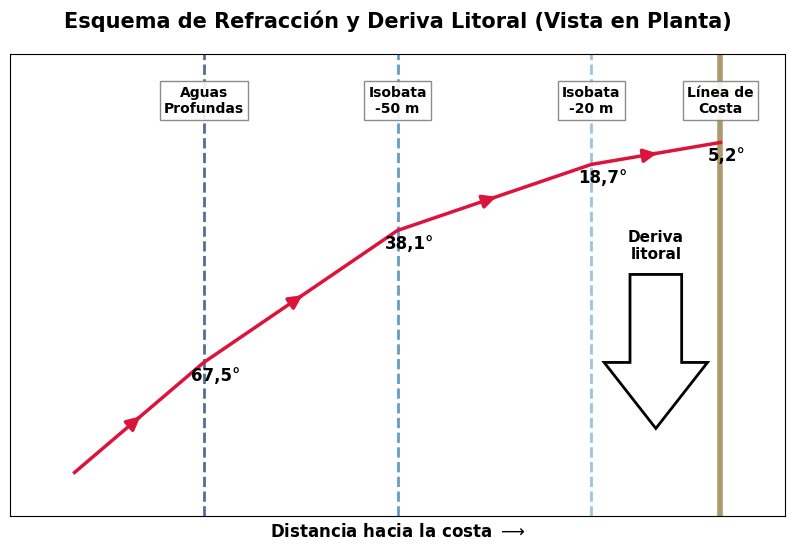

In [13]:
# ============================================================
# CELDA 11: ESQUEMA DE REFRACCIÓN Y DERIVA LITORAL (Punto 4b)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

print("Generando esquema con flechas de dirección normales...")

fig, ax = plt.subplots(figsize=(10, 6))

# 1. Posiciones de las Isobatas
x_isobatas = [80, 50, 20, 0]
profundidades = ['Aguas\nProfundas', 'Isobata\n-50 m', 'Isobata\n-20 m', 'Línea de\nCosta']
colores_lineas = ['#08306b', '#2171b5', '#6baed6', '#8c6d31']

for x, label, color in zip(x_isobatas, profundidades, colores_lineas):
    lw = 4 if 'Costa' in label else 2
    ls = '-' if 'Costa' in label else '--'
    ax.axvline(x=x, color=color, linestyle=ls, linewidth=lw, alpha=0.7, zorder=2)
    # Etiquetas claras en la parte superior
    ax.text(x, 98, label, ha='center', va='top', fontweight='bold', color='black',
            fontsize=10, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', pad=3), zorder=6)

# 2. Rayo de ola (Trayectoria con refracción)
x_ray = np.array([100, 80, 50, 20, 0])
y_ray = np.array([10, 35, 65, 80, 85])

# Trazar el rayo principal
ax.plot(x_ray, y_ray, color='crimson', linewidth=2.5, zorder=4)

# Añadir flechas clásicas ("normales") sobre el rayo
for i in range(len(x_ray)-1):
    x_mid = (x_ray[i] + x_ray[i+1]) / 2
    y_mid = (y_ray[i] + y_ray[i+1]) / 2
    dx = x_ray[i+1] - x_ray[i]
    dy = y_ray[i+1] - y_ray[i]

    # Dibujamos una punta de flecha sólida estándar en la mitad de cada segmento
    ax.annotate('', xy=(x_mid + dx*0.01, y_mid + dy*0.01), xytext=(x_mid, y_mid),
                arrowprops=dict(arrowstyle="-|>", color='crimson', lw=2.5, mutation_scale=20), zorder=5)

# 3. Ángulos explícitos
angulos = ['67,5°', '38,1°', '18,7°', '5,2°']
for x, y, angulo in zip(x_ray[1:], y_ray[1:], angulos):
    ax.text(x + 2, y - 4, angulo, fontsize=12, fontweight='bold', color='black', zorder=6)

# 4. Flecha de Deriva Litoral
flecha_x = [6, 14, 14, 18, 10, 2, 6]
flecha_y = [55, 55, 35, 35, 20, 35, 35]
ax.fill(flecha_x, flecha_y, facecolor='white', edgecolor='black', linewidth=2, zorder=5)
ax.text(10, 58, 'Deriva\nlitoral', ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

# 5. Estética general
ax.set_xlim(-10, 110)
ax.set_ylim(0, 105)
ax.invert_xaxis() # La costa a la izquierda y aguas profundas a la derecha
ax.set_title('Esquema de Refracción y Deriva Litoral (Vista en Planta)', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Distancia hacia la costa $\longrightarrow$', fontsize=12, fontweight='bold')
ax.set_yticks([])
ax.set_xticks([])
ax.grid(False)

plt.show()

Generando esquemas de propagación...


<>:58: SyntaxWarning: invalid escape sequence '\l'
<>:58: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_711/2390088740.py:58: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Distancia hacia la costa $\longrightarrow$', fontsize=12, fontweight='bold')


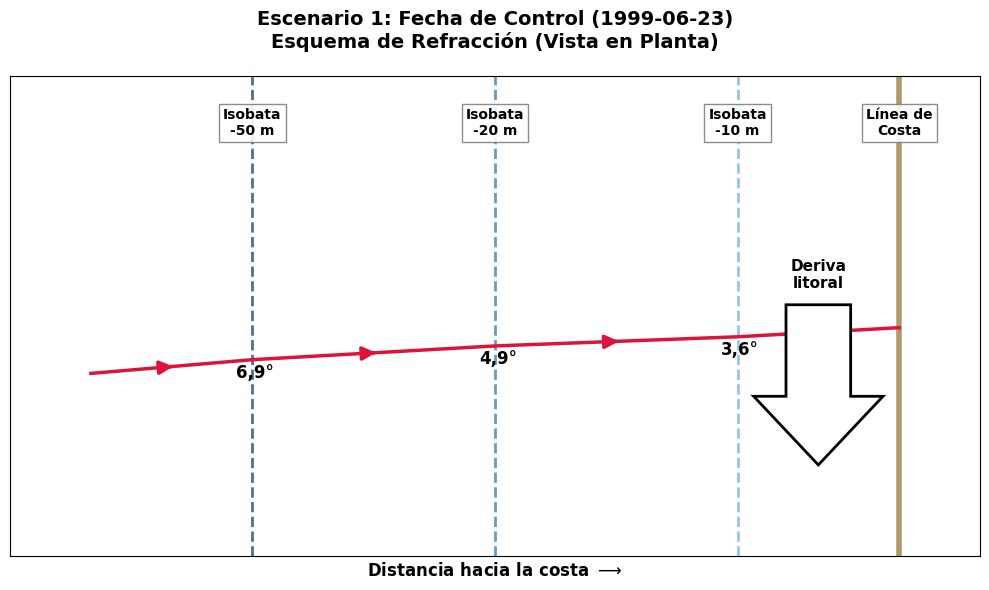

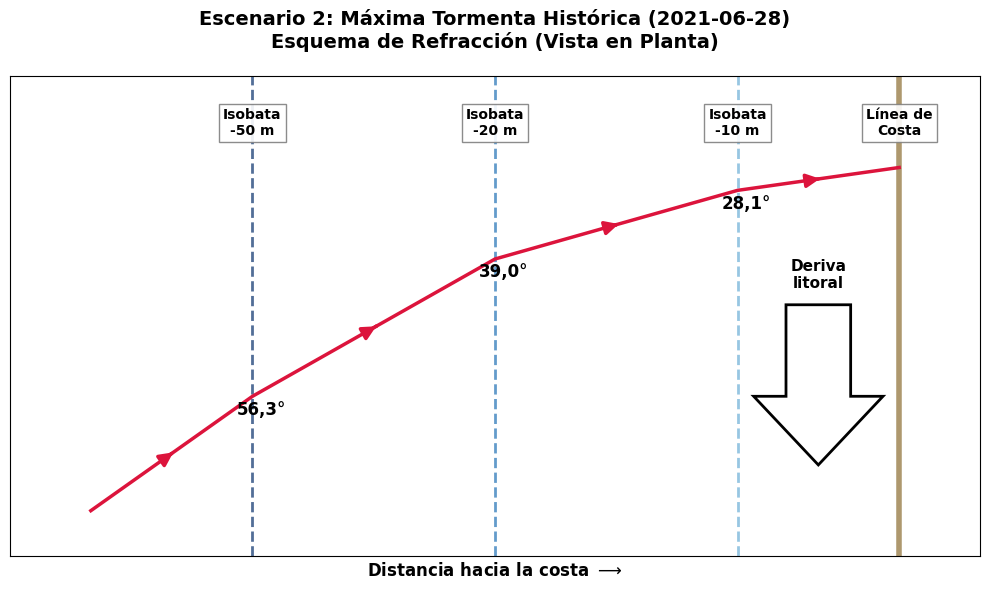

In [14]:
# ============================================================
# CELDA 11: ESQUEMAS DE REFRACCIÓN Y DERIVA LITORAL (Punto 4b)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

print("Generando esquemas de propagación...")

def graficar_refraccion(escenario_num, titulo, y_ray, angulos):
    fig, ax = plt.subplots(figsize=(10, 6))

    # 1. Posiciones de las Isobatas (Ajustadas a 50m, 20m y 10m)
    x_isobatas = [80, 50, 20, 0]
    profundidades = ['Isobata\n-50 m', 'Isobata\n-20 m', 'Isobata\n-10 m', 'Línea de\nCosta']
    colores_lineas = ['#08306b', '#2171b5', '#6baed6', '#8c6d31']

    for x, label, color in zip(x_isobatas, profundidades, colores_lineas):
        lw = 4 if 'Costa' in label else 2
        ls = '-' if 'Costa' in label else '--'
        ax.axvline(x=x, color=color, linestyle=ls, linewidth=lw, alpha=0.7, zorder=2)
        # Etiquetas claras en la parte superior
        ax.text(x, 98, label, ha='center', va='top', fontweight='bold', color='black',
                fontsize=10, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', pad=3), zorder=6)

    # 2. Rayo de ola (Trayectoria con refracción)
    x_ray = np.array([100, 80, 50, 20, 0])

    # Trazar el rayo principal
    ax.plot(x_ray, y_ray, color='crimson', linewidth=2.5, zorder=4)

    # Añadir flechas clásicas ("normales") sobre el rayo
    for i in range(len(x_ray)-1):
        x_mid = (x_ray[i] + x_ray[i+1]) / 2
        y_mid = (y_ray[i] + y_ray[i+1]) / 2
        dx = x_ray[i+1] - x_ray[i]
        dy = y_ray[i+1] - y_ray[i]

        # Dibujamos una punta de flecha sólida estándar en la mitad de cada segmento
        ax.annotate('', xy=(x_mid + dx*0.01, y_mid + dy*0.01), xytext=(x_mid, y_mid),
                    arrowprops=dict(arrowstyle="-|>", color='crimson', lw=2.5, mutation_scale=20), zorder=5)

    # 3. Ángulos explícitos (se imprimen los 3 correspondientes a las isobatas)
    for x, y, angulo in zip(x_ray[1:4], y_ray[1:4], angulos):
        ax.text(x + 2, y - 4, angulo, fontsize=12, fontweight='bold', color='black', zorder=6)

    # 4. Flecha de Deriva Litoral
    flecha_x = [6, 14, 14, 18, 10, 2, 6]
    flecha_y = [55, 55, 35, 35, 20, 35, 35]
    ax.fill(flecha_x, flecha_y, facecolor='white', edgecolor='black', linewidth=2, zorder=5)
    ax.text(10, 58, 'Deriva\nlitoral', ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

    # 5. Estética general
    ax.set_xlim(-10, 110)
    ax.set_ylim(0, 105)
    ax.invert_xaxis() # La costa a la izquierda y aguas profundas a la derecha
    ax.set_title(f'Escenario {escenario_num}: {titulo}\nEsquema de Refracción (Vista en Planta)',
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Distancia hacia la costa $\longrightarrow$', fontsize=12, fontweight='bold')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.grid(False)

    plt.tight_layout()
    plt.show()

# ============================================================
# GENERACIÓN DE LOS GRÁFICOS
# ============================================================

# --- ESCENARIO 1 ---
# Ángulos muy chicos, por lo que la trayectoria visualmente casi no se curva
y_ray_1 = np.array([40, 43, 46, 48, 50])
angulos_1 = ['6,9°', '4,9°', '3,6°']
graficar_refraccion(1, 'Fecha de Control (1999-06-23)', y_ray_1, angulos_1)

# --- ESCENARIO 2 ---
# Ángulos oblicuos grandes, fuerte refracción y curvatura hacia la costa
y_ray_2 = np.array([10, 35, 65, 80, 85])
angulos_2 = ['56,3°', '39,0°', '28,1°']
graficar_refraccion(2, 'Máxima Tormenta Histórica (2021-06-28)', y_ray_2, angulos_2)

In [15]:
# ============================================================
# CELDA 12: MAPA SINÓPTICO DE PRESIÓN Y VIENTO (Punto 5)
# ============================================================
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

print("Generando mapa de presión al nivel del mar y vientos...")

# ---> ¡PONÉ ACÁ LA RUTA DE TU ARCHIVO ERA5 DESCARGADO! <---
archivo_era5 = "/content/Campo.Presion.MDQ.28-06-2021.nc"

try:
    ds_atmos = xr.open_dataset(archivo_era5)
except FileNotFoundError:
    print("⚠️ Archivo no encontrado. Revisá la ruta de tu archivo ERA5.")
else:
    # SOLUCIÓN AL ERROR: Chequeamos cómo se llama la dimensión de tiempo en tu archivo
    time_dim = 'valid_time' if 'valid_time' in ds_atmos.dims else 'time'

    # Ajustamos variables según nomenclatura estándar de ERA5
    # Convertimos presión de Pascales a Hectopascales (hPa)
    presion_hpa = ds_atmos['msl'].isel({time_dim: 0}) / 100.0
    u_wind = ds_atmos['u10'].isel({time_dim: 0})
    v_wind = ds_atmos['v10'].isel({time_dim: 0})

    # Extraemos lat/lon (ERA5 a veces usa 'longitude' o 'lon')
    lon_name = 'longitude' if 'longitude' in ds_atmos.coords else 'lon'
    lat_name = 'latitude' if 'latitude' in ds_atmos.coords else 'lat'
    lons = ds_atmos[lon_name].values
    lats = ds_atmos[lat_name].values

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection=ccrs.PlateCarree())
    ax.set_extent([-70, -40, -60, -30], crs=ccrs.PlateCarree())

    # Capas base cartográficas
    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#e6e6e6', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='#f4f7f9', zorder=0)
    ax.coastlines(resolution='50m', color='black', linewidth=1.2, zorder=2)

    # 1. Trazar Isobaras (Contornos de Presión)
    niveles_presion = np.arange(950, 1040, 4)
    cs = ax.contour(lons, lats, presion_hpa, levels=niveles_presion,
                    colors='#1a3a5c', linewidths=1.5, transform=ccrs.PlateCarree(), zorder=3)
    # Etiquetas de presión con recuadro blanco para mejor lectura
    ax.clabel(cs, inline=True, fontsize=10, fmt='%d hPa', colors='black')

    # 2. Trazar Vectores de Viento (Quiver)
    # Filtramos las flechas para que el mapa no quede saturado de negro
    salto = 3
    ax.quiver(lons[::salto], lats[::salto], u_wind[::salto, ::salto], v_wind[::salto, ::salto],
              transform=ccrs.PlateCarree(), color='crimson', width=0.0015, scale=400, zorder=4, alpha=0.8)

    # 3. Marcador del Área de Estudio (Nodo WAVERYS)
    lon_estudio, lat_estudio = -57.5, -38.0
    ax.plot(lon_estudio, lat_estudio, marker='*', color='#e6a800', markeredgecolor='black', markersize=18,
            transform=ccrs.PlateCarree(), zorder=5, label='Nodo de Estudio')

    # Grilla y Leyenda
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5, zorder=2)
    gl.top_labels = False; gl.right_labels = False
    ax.legend(loc='upper right', framealpha=0.9)

    # Título estilizado (usando el nombre de dimensión dinámico)
    fecha_mapa = str(ds_atmos[time_dim].values[0])[:16].replace('T', ' ')
    ax.set_title(f'Campo Sinóptico del Evento Extremo ({fecha_mapa})\nPresión al Nivel del Mar y Vientos a 10m',
                 fontsize=14, fontweight='bold', pad=15)
    plt.show()

Generando mapa de presión al nivel del mar y vientos...
⚠️ Archivo no encontrado. Revisá la ruta de tu archivo ERA5.


In [16]:
# ============================================================
# CELDA 12: MAPA SINÓPTICO DE PRESIÓN Y VIENTO CON ZOOM (Punto 5)
# ============================================================
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import numpy as np

print("Generando mapa de presión al nivel del mar y vientos (General + Zoom)...")

# ---> ¡PONÉ ACÁ LA RUTA DE TU ARCHIVO ERA5 DESCARGADO! <---
archivo_era5 = "/content/Campo.Presion.MDQ.28-06-2021.nc"

try:
    ds_atmos = xr.open_dataset(archivo_era5)
except FileNotFoundError:
    print("⚠️ Archivo no encontrado. Revisá la ruta de tu archivo ERA5.")
else:
    # Chequeamos cómo se llama la dimensión de tiempo en tu archivo
    time_dim = 'valid_time' if 'valid_time' in ds_atmos.dims else 'time'

    # Convertimos presión de Pascales a Hectopascales (hPa)
    presion_hpa = ds_atmos['msl'].isel({time_dim: 0}) / 100.0
    u_wind = ds_atmos['u10'].isel({time_dim: 0})
    v_wind = ds_atmos['v10'].isel({time_dim: 0})

    lon_name = 'longitude' if 'longitude' in ds_atmos.coords else 'lon'
    lat_name = 'latitude' if 'latitude' in ds_atmos.coords else 'lat'
    lons = ds_atmos[lon_name].values
    lats = ds_atmos[lat_name].values

    # =====================================================
    # CONFIGURACIÓN DE LA FIGURA (2 PANELES)
    # =====================================================
    fig = plt.figure(figsize=(16, 8))

    # Eje 1: Mapa General (Izquierda)
    ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
    extent_main = [-70, -40, -60, -30]
    ax1.set_extent(extent_main, crs=ccrs.PlateCarree())

    # Eje 2: Mapa Zoom (Derecha)
    ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
    extent_zoom = [-61, -54, -41, -35] # Coordenadas ajustadas sobre la costa bonaerense
    ax2.set_extent(extent_zoom, crs=ccrs.PlateCarree())

    # =====================================================
    # FUNCIÓN PARA DIBUJAR CAPAS (Evita repetir código)
    # =====================================================
    def configurar_mapa(ax, es_zoom=False):
        ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#e6e6e6', edgecolor='black', zorder=1)
        ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='#f4f7f9', zorder=0)
        ax.coastlines(resolution='50m', color='black', linewidth=1.2, zorder=2)

        # 1. Isobaras
        niveles_presion = np.arange(950, 1040, 4)
        cs = ax.contour(lons, lats, presion_hpa, levels=niveles_presion,
                        colors='#1a3a5c', linewidths=1.5, transform=ccrs.PlateCarree(), zorder=3)
        # En el zoom usamos formato sin "hPa" para no saturar visualmente
        fmt_label = '%d' if es_zoom else '%d hPa'
        ax.clabel(cs, inline=True, fontsize=10, fmt=fmt_label, colors='black')

        # 2. Vientos (Quiver)
        # Si es el zoom, graficamos cada flecha (salto=1) y ajustamos la escala para que se vean bien
        salto = 1 if es_zoom else 3
        escala_flechas = 200 if es_zoom else 400

        ax.quiver(lons[::salto], lats[::salto], u_wind[::salto, ::salto], v_wind[::salto, ::salto],
                  transform=ccrs.PlateCarree(), color='crimson', width=0.002,
                  scale=escala_flechas, zorder=4, alpha=0.8)

        # 3. Marcador del Área de Estudio
        lon_estudio, lat_estudio = -57.5, -38.0
        ax.plot(lon_estudio, lat_estudio, marker='*', color='#e6a800', markeredgecolor='black',
                markersize=18 if not es_zoom else 25, transform=ccrs.PlateCarree(), zorder=5,
                label='Nodo de Estudio')

        # Grilla
        gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5, zorder=2)
        gl.top_labels = False
        gl.right_labels = False

    # =====================================================
    # APLICAMOS LA FUNCIÓN A AMBOS MAPAS
    # =====================================================
    configurar_mapa(ax1, es_zoom=False)
    configurar_mapa(ax2, es_zoom=True)

    ax1.legend(loc='upper right', framealpha=0.9)
    ax2.set_title("Detalle del Viento en la Costa Bonaerense", fontsize=12, fontweight='bold', pad=10)

    # Dibujamos un polígono rojo en el mapa general para referenciar el área del zoom
    rect_zoom = mpatches.Rectangle((extent_zoom[0], extent_zoom[2]),
                                   width=extent_zoom[1] - extent_zoom[0],
                                   height=extent_zoom[3] - extent_zoom[2],
                                   linewidth=2, edgecolor='red', facecolor='none',
                                   linestyle='--', transform=ccrs.PlateCarree(), zorder=6)
    ax1.add_patch(rect_zoom)

    # =====================================================
    # TÍTULO PRINCIPAL DE LA FIGURA
    # =====================================================
    fecha_mapa = str(ds_atmos[time_dim].values[0])[:16].replace('T', ' ')
    fig.suptitle(f'Campo Sinóptico del Evento Extremo ({fecha_mapa})\nPresión al Nivel del Mar y Vientos a 10m',
                 fontsize=16, fontweight='bold', y=1.02)

    # Ajustamos márgenes para que no se superpongan
    plt.tight_layout()
    plt.show()

Generando mapa de presión al nivel del mar y vientos (General + Zoom)...
⚠️ Archivo no encontrado. Revisá la ruta de tu archivo ERA5.


In [17]:
# ============================================================
# CELDA 12: MAPA SINÓPTICO DE PRESIÓN Y VIENTO CON ZOOM Y CENTROS (Punto 5)
# ============================================================
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import numpy as np

print("Generando mapa de presión al nivel del mar y vientos (General + Zoom)...")

# ---> ¡PONÉ ACÁ LA RUTA DE TU ARCHIVO ERA5 DESCARGADO! <---
archivo_era5 = "/content/Campo.Presion.MDQ.28-06-2021.nc"

try:
    ds_atmos = xr.open_dataset(archivo_era5)
except FileNotFoundError:
    print("⚠️ Archivo no encontrado. Revisá la ruta de tu archivo ERA5.")
else:
    time_dim = 'valid_time' if 'valid_time' in ds_atmos.dims else 'time'

    presion_hpa = ds_atmos['msl'].isel({time_dim: 0}) / 100.0
    u_wind = ds_atmos['u10'].isel({time_dim: 0})
    v_wind = ds_atmos['v10'].isel({time_dim: 0})

    lon_name = 'longitude' if 'longitude' in ds_atmos.coords else 'lon'
    lat_name = 'latitude' if 'latitude' in ds_atmos.coords else 'lat'
    lons = ds_atmos[lon_name].values
    lats = ds_atmos[lat_name].values

    # =====================================================
    # BUSCADOR AUTOMÁTICO DE CENTROS (A / B)
    # =====================================================
    # Encontramos los índices de la matriz donde la presión es máxima y mínima
    presion_vals = presion_hpa.values
    idx_min = np.unravel_index(np.argmin(presion_vals), presion_vals.shape)
    idx_max = np.unravel_index(np.argmax(presion_vals), presion_vals.shape)

    # Identificamos la latitud y longitud exacta de esos puntos
    if lons.ndim == 1:
        lon_baja, lat_baja = lons[idx_min[1]], lats[idx_min[0]]
        lon_alta, lat_alta = lons[idx_max[1]], lats[idx_max[0]]
    else:
        lon_baja, lat_baja = lons[idx_min], lats[idx_min]
        lon_alta, lat_alta = lons[idx_max], lats[idx_max]

    # =====================================================
    # CONFIGURACIÓN DE LA FIGURA
    # =====================================================
    fig = plt.figure(figsize=(16, 8))

    # Eje 1: Mapa General
    ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
    extent_main = [-70, -40, -60, -30]
    ax1.set_extent(extent_main, crs=ccrs.PlateCarree())

    # Eje 2: Mapa Zoom
    ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
    extent_zoom = [-61, -54, -41, -35]
    ax2.set_extent(extent_zoom, crs=ccrs.PlateCarree())

    def configurar_mapa(ax, es_zoom=False):
        ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#e6e6e6', edgecolor='black', zorder=1)
        ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='#f4f7f9', zorder=0)
        ax.coastlines(resolution='50m', color='black', linewidth=1.2, zorder=2)

        niveles_presion = np.arange(950, 1040, 4)
        cs = ax.contour(lons, lats, presion_hpa, levels=niveles_presion,
                        colors='#1a3a5c', linewidths=1.5, transform=ccrs.PlateCarree(), zorder=3)
        fmt_label = '%d' if es_zoom else '%d hPa'
        ax.clabel(cs, inline=True, fontsize=10, fmt=fmt_label, colors='black')

        salto = 1 if es_zoom else 3
        escala_flechas = 200 if es_zoom else 400

        ax.quiver(lons[::salto], lats[::salto], u_wind[::salto, ::salto], v_wind[::salto, ::salto],
                  transform=ccrs.PlateCarree(), color='crimson', width=0.002,
                  scale=escala_flechas, zorder=4, alpha=0.8)

        lon_estudio, lat_estudio = -57.5, -38.0
        ax.plot(lon_estudio, lat_estudio, marker='*', color='#e6a800', markeredgecolor='black',
                markersize=18 if not es_zoom else 25, transform=ccrs.PlateCarree(), zorder=5,
                label='Nodo de Estudio')

        gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5, zorder=2)
        gl.top_labels = False; gl.right_labels = False

    configurar_mapa(ax1, es_zoom=False)
    configurar_mapa(ax2, es_zoom=True)

    ax1.legend(loc='upper right', framealpha=0.9)
    ax2.set_title("Detalle del Viento en la Costa Bonaerense", fontsize=12, fontweight='bold', pad=10)

    rect_zoom = mpatches.Rectangle((extent_zoom[0], extent_zoom[2]),
                                   width=extent_zoom[1] - extent_zoom[0],
                                   height=extent_zoom[3] - extent_zoom[2],
                                   linewidth=2, edgecolor='red', facecolor='none',
                                   linestyle='--', transform=ccrs.PlateCarree(), zorder=6)
    ax1.add_patch(rect_zoom)

    # =====================================================
    # DIBUJAR LETRAS DE LOS CENTROS (B y A) EN EL MAPA GENERAL
    # =====================================================
    # Letra 'B' para la Baja Presión (Ciclón)
    ax1.text(lon_baja, lat_baja, 'B', color='red', fontsize=22, fontweight='bold',
             ha='center', va='center', transform=ccrs.PlateCarree(), zorder=10,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

    # Letra 'A' para la Alta Presión (Anticiclón)
    ax1.text(lon_alta, lat_alta, 'A', color='blue', fontsize=22, fontweight='bold',
             ha='center', va='center', transform=ccrs.PlateCarree(), zorder=10,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

    fecha_mapa = str(ds_atmos[time_dim].values[0])[:16].replace('T', ' ')
    fig.suptitle(f'Campo Sinóptico del Evento Extremo ({fecha_mapa})\nPresión al Nivel del Mar y Vientos a 10m',
                 fontsize=16, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

Generando mapa de presión al nivel del mar y vientos (General + Zoom)...
⚠️ Archivo no encontrado. Revisá la ruta de tu archivo ERA5.


Extrayendo máximos anuales y analizando tendencia...


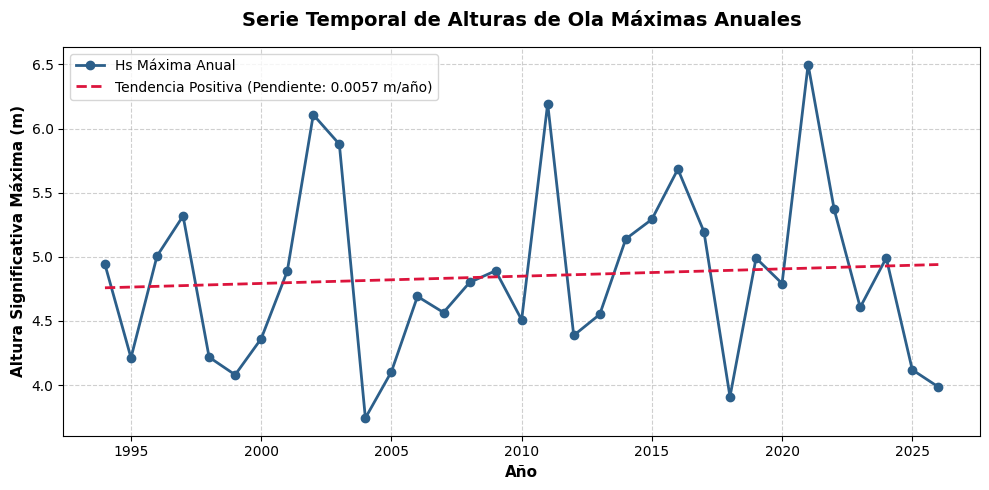

La pendiente de la tendencia es 0.0057 metros por año.


In [18]:
# ============================================================
# CELDA 12: ALTURAS MÁXIMAS ANUALES Y TENDENCIA (Punto 6a)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

print("Extrayendo máximos anuales y analizando tendencia...")

if 'ds_regional' in locals():
    # 1. Agrupamos los datos por año y extraemos la altura máxima
    max_anuales = ds_regional['VHM0'].groupby('time.year').max()

    # Convertimos a DataFrame para facilitar el manejo
    df_max = max_anuales.to_dataframe().reset_index()
    df_max = df_max.rename(columns={'year': 'Año', 'VHM0': 'Hs_max'})
    df_max = df_max.dropna()

    # 2. Análisis de tendencia (Regresión Lineal)
    slope, intercept, r_value, p_value, std_err = linregress(df_max['Año'], df_max['Hs_max'])
    df_max['Tendencia'] = slope * df_max['Año'] + intercept

    # 3. Gráfico
    fig, ax = plt.subplots(figsize=(10, 5))

    # Puntos de los máximos anuales
    ax.plot(df_max['Año'], df_max['Hs_max'], marker='o', linestyle='-', color='#2c5f8a',
            linewidth=2, markersize=6, label='Hs Máxima Anual')

    # Línea de tendencia
    tendencia_str = 'Positiva' if slope > 0 else 'Negativa'
    ax.plot(df_max['Año'], df_max['Tendencia'], color='crimson', linestyle='--', linewidth=2,
            label=f'Tendencia {tendencia_str} (Pendiente: {slope:.4f} m/año)')

    ax.set_title('Serie Temporal de Alturas de Ola Máximas Anuales', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Año', fontsize=11, fontweight='bold')
    ax.set_ylabel('Altura Significativa Máxima (m)', fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper left', fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"La pendiente de la tendencia es {slope:.4f} metros por año.")
else:
    print("⚠️ Por favor, ejecutá la celda que define 'ds_regional' primero.")

In [19]:
# ============================================================
# CELDA 13: VALORES EXTREMOS, PERÍODOS DE RETORNO Y RIESGO (Puntos 6b, c, d)
# ============================================================
from IPython.display import display

print("Calculando ajustes de distribuciones y proyecciones...")

# 1. ORDENAMIENTO Y PROBABILIDAD EMPÍRICA
# Ordenamos de menor a mayor
Hs_sort = np.sort(df_max['Hs_max'].values)
N = len(Hs_sort)
rango = np.arange(1, N + 1)
# Probabilidad de no excedencia empírica P(X <= x) = m / (N+1)
P_emp = rango / (N + 1)

# 2. DEFINICIÓN DE VARIABLES REDUCIDAS PARA LINEALIZACIÓN
# Gumbel: y = -ln(-ln(P))
y_gumbel = -np.log(-np.log(P_emp))

# Weibull: y = (-ln(1 - P))^(1/k)
def y_weibull(P, k):
    return (-np.log(1 - P))**(1/k)

# 3. AJUSTE LINEAL (Hs = a*y + b) Y EVALUACIÓN DE CORRELACIÓN (R)
ajustes = {}

# Ajuste Gumbel
slope_g, intercept_g, r_g, p_g, std_g = linregress(y_gumbel, Hs_sort)
ajustes['Gumbel'] = {'R': r_g, 'a': slope_g, 'b': intercept_g, 'tipo': 'Gumbel', 'k': None}

# Ajustes Weibull
k_vals = [0.75, 1.0, 2.0]
for k in k_vals:
    y_w = y_weibull(P_emp, k)
    slope_w, intercept_w, r_w, p_w, std_w = linregress(y_w, Hs_sort)
    ajustes[f'Weibull (k={k})'] = {'R': r_w, 'a': slope_w, 'b': intercept_w, 'tipo': 'Weibull', 'k': k}

# 4. SELECCIÓN DE LA MEJOR DISTRIBUCIÓN (Inciso 6b)
# Buscamos la que tenga el coeficiente R más cercano a 1
mejor_ajuste_nombre = max(ajustes, key=lambda key: ajustes[key]['R'])
mejor_ajuste = ajustes[mejor_ajuste_nombre]

df_ajustes = pd.DataFrame([
    {'Distribución': k, 'Coef. Correlación (R)': v['R'], 'Pendiente (a)': v['a'], 'Ordenada (b)': v['b']}
    for k, v in ajustes.items()
]).sort_values('Coef. Correlación (R)', ascending=False)

print("\n--- 6b) COMPARACIÓN DE AJUSTES ---")
display(df_ajustes.style.hide(axis="index").set_caption("Ajustes Lineales (Ordenados por R)").format(precision=4))
print(f"👉 La distribución con mejor ajuste es: {mejor_ajuste_nombre} (R = {mejor_ajuste['R']:.4f})")

# 5. CÁLCULO DE PERÍODOS DE RETORNO (Inciso 6c)
Tr_vals = [5, 10, 25, 50, 100]
proyecciones = []

for Tr in Tr_vals:
    # Probabilidad teórica para el Tr
    P_teorica = 1 - (1 / Tr)

    # Calculamos la variable reducida 'y' según la distribución ganadora
    if mejor_ajuste['tipo'] == 'Gumbel':
        y_teorico = -np.log(-np.log(P_teorica))
    else:
        y_teorico = y_weibull(P_teorica, mejor_ajuste['k'])

    # Despejamos Hs con la ecuación lineal de la distribución ganadora
    Hs_Tr = mejor_ajuste['a'] * y_teorico + mejor_ajuste['b']
    proyecciones.append({'Período de Retorno (Años)': Tr, 'Altura de Ola Hs (m)': Hs_Tr})

df_proy = pd.DataFrame(proyecciones)

print(f"\n--- 6c) ALTURAS DE OLA PARA PERÍODOS DE RETORNO (Usando {mejor_ajuste_nombre}) ---")
display(df_proy.style.hide(axis="index").format(precision=2))

# 6. PROBABILIDAD DE ENCUENTRO PARA ESTRUCTURA COSTERA (Inciso 6d)
# Asumimos una vida útil (L) estándar de obra marítima: 50 años
Vida_Util = 50
Tr_obj = 100

# Fórmula matemática: E = 1 - (1 - 1/Tr)^L
Riesgo_Encuentro = 1 - (1 - (1 / Tr_obj))**Vida_Util

print("\n--- 6d) PROBABILIDAD DE ENCUENTRO ---")
print(f"Para una estructura costera con una vida útil de {Vida_Util} años,")
print(f"la probabilidad de que se encuentre con la ola centenaria (Tr = 100 años) durante su existencia es:")
print(f"E = 1 - (1 - 1/{Tr_obj})^{Vida_Util}")
print(f"E = {Riesgo_Encuentro * 100:.2f} %")

Calculando ajustes de distribuciones y proyecciones...

--- 6b) COMPARACIÓN DE AJUSTES ---


Distribución,Coef. Correlación (R),Pendiente (a),Ordenada (b)
Gumbel,0.9953,0.5977,4.5273
Weibull (k=2.0),0.9941,1.5802,3.4636
Weibull (k=1.0),0.9758,0.7782,4.1109
Weibull (k=0.75),0.9437,0.5113,4.2952


👉 La distribución con mejor ajuste es: Gumbel (R = 0.9953)

--- 6c) ALTURAS DE OLA PARA PERÍODOS DE RETORNO (Usando Gumbel) ---


Período de Retorno (Años),Altura de Ola Hs (m)
5,5.42
10,5.87
25,6.44
50,6.86
100,7.28



--- 6d) PROBABILIDAD DE ENCUENTRO ---
Para una estructura costera con una vida útil de 50 años,
la probabilidad de que se encuentre con la ola centenaria (Tr = 100 años) durante su existencia es:
E = 1 - (1 - 1/100)^50
E = 39.50 %
